In [1]:
import torch
import torch.nn as nn

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid
import os
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("traurigdrachen/foresttrain")

# print("Path to dataset files:", path)

In [3]:
# dataset_path = './datasets/dataset_rbmk/clear'

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 32


hidden_dim = 400
latent_dim = 512

lr = 1e-3
num_epochs = 50

In [4]:


dataset_path = '/kaggle/input/datasets/traurigdrachen/foresttrain'
# 2. Ajuste as transformações
# Nota: Como são imagens de satélite, talvez você precise de Resize ou Grayscale
# dependendo da arquitetura do seu VAE.
novo_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),            # [0, 255] -> [0, 1]
    # transforms.Grayscale(num_output_channels=1) # Descomente se quiser forçar P&B
])
kwargs = {'num_workers': 1, 'pin_memory': True} if torch.cuda.is_available() else {}
# 3. Carregue o dataset completo
full_dataset = ImageFolder(root=dataset_path, transform=novo_transform)

# 4. Divisão em Treino e Teste (Já que você não tem pastas separadas nativamente)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 5. DataLoaders permanecem quase iguais
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

# --- Verificação das dimensões ---
# Para acessar a primeira imagem no ImageFolder dentro de um Subset:
amostra_x, rotulo = full_dataset[0]
canais, altura, largura = amostra_x.shape

input_channels = canais

print(f"--- Info da Amostra RBMK ---")
print(f"Dimensões da Imagem: {canais} canais x {altura}px x {largura}px")
print(f"Total de imagens encontradas: {len(full_dataset)}")

--- Info da Amostra RBMK ---
Dimensões da Imagem: 3 canais x 128px x 128px
Total de imagens encontradas: 28431


In [5]:
# from torchvision.datasets import MNIST
# import torchvision.transforms as transforms
# from torch.utils.data import DataLoader

# mnist_transform = transforms.Compose([
#     transforms.ToTensor(), # [0, 255] -> [0, 1]
# ])

# kwargs = {'num_workers': 1, 'pin_memory': True} if torch.cuda.is_available() else {}

# train_dataset = MNIST(dataset_path, train=True, transform=mnist_transform, download=True)
# test_dataset = MNIST(dataset_path, train=False, transform=mnist_transform, download=True)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **kwargs)

# canais_img = train_dataset[0][0].shape[0]
# input_channels = canais_img
# print(f'Número de canais da imagem: {canais_img}')

# # Acessando o primeiro item do dataset
# amostra_x, rotulo = train_dataset[0]

# # Extraindo dimensões
# canais = amostra_x.shape[0]
# altura = amostra_x.shape[1]
# largura = amostra_x.shape[2]

# print(f"--- Info da Amostra ---")
# print(f"Dimensões da Imagem: {canais} canais x {altura}px x {largura}px")
# print(f"Rótulo (Label): {rotulo}")

In [6]:
# '''
# implementation of Gaussian MLP
# '''

# class Encoder(nn.Module):
#     def __init__(self, x_dim, hidden_dim, latent_dim):
#         super(Encoder, self).__init__()
#         self.fc1 = nn.Linear(x_dim, hidden_dim) #ax + b
#         self.fc2 = nn.Linear(hidden_dim, hidden_dim)
#         self.fc3_mean = nn.Linear(hidden_dim, latent_dim)
#         self.fc3_logvar = nn.Linear(hidden_dim, latent_dim)

#         self.LeakyReLU = nn.LeakyReLU(0.2) # ela evita o problema de gradiente nulo, mesmo quando a entrada é negativa, o que pode ocorrer durante o treinamento.


#         self.training = True

#     def forward(self, x):
#         h_ = self.LeakyReLU(self.fc1(x))
#         h_ = self.LeakyReLU(self.fc2(h_))
#         mean = self.fc3_mean(h_)
#         logvar = self.fc3_logvar(h_)
#         return mean, logvar

In [7]:
class Encoder(nn.Module):
    def __init__(self, input_channels, latent_dim):
        super(Encoder, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Input: (input_channels, 128, 128)
            nn.Conv2d(input_channels, 32, 3, stride=2, padding=1),  # -> 64x64
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(32, 64, 3, stride=2, padding=1),             # -> 32x32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(64, 128, 3, stride=2, padding=1),            # -> 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            
            nn.Conv2d(128, 256, 3, stride=2, padding=1),           # -> 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 3, stride=2, padding=1),           # -> 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            
            nn.Flatten()
        )
        
        # Volume final: 512 canais * 4 * 4 = 8192
        self.flat_features = 512 * 4 * 4
        
        self.fc_mean = nn.Linear(self.flat_features, latent_dim)
        self.fc_logvar = nn.Linear(self.flat_features, latent_dim)

    def forward(self, x):
        h = self.conv_layers(x)
        return self.fc_mean(h), self.fc_logvar(h)

In [8]:
# class Decoder(nn.Module):
#     def __init__(self, latent_dim, hidden_dim, y_dim):
#         super(Decoder, self).__init__()
#         self.fc1 = nn.Linear(latent_dim, hidden_dim)
#         self.fc2 = nn.Linear(hidden_dim, hidden_dim)
#         self.fc3 = nn.Linear(hidden_dim, y_dim)

#         self.LeakyReLU = nn.LeakyReLU(0.2)

#     def forward(self, z):
#         h = self.LeakyReLU(self.fc1(z))
#         h = self.LeakyReLU(self.fc2(h))
#         y_hat = torch.sigmoid(self.fc3(h))
#         return y_hat

In [9]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, output_channels):
        super(Decoder, self).__init__()

        self.flat_features = 512 * 4 * 4
        self.fc_upsample = nn.Linear(latent_dim, self.flat_features)

        self.deconv_layers = nn.Sequential(
            # Entrada: [Batch, 512, 4, 4] -> 8x8
            nn.ConvTranspose2d(512, 256, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # 16x16 -> 32x32
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),

            # 64x64 -> 128x128
            nn.ConvTranspose2d(32, output_channels, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() 
        )

    def forward(self, z):
        h = self.fc_upsample(z)
        h = h.view(-1, 512, 4, 4)
        return self.deconv_layers(h)

In [10]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterize(self, mean, logvar):
        dp = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(dp).to(DEVICE)
        z = mean + dp * epsilon
        return z

    def forward(self, x):
        mean, logvar = self.Encoder(x)
        z = self.reparameterize(mean, logvar)
        y_hat = self.Decoder(z)
        return y_hat, mean, logvar


In [11]:
# encoder = Encoder(x_dim, hidden_dim, latent_dim)
# decoder = Decoder(latent_dim, hidden_dim, x_dim)

encoder = Encoder(input_channels, latent_dim)
decoder = Decoder(latent_dim, input_channels)

model = Model(encoder, decoder).to(DEVICE)
print("model: ", model)

model:  Model(
  (Encoder): Encoder(
    (conv_layers): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
      (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2)
      (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): LeakyReLU(negative_slope=0.2)
      (12): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (13)

In [12]:
from torch.optim import Adam

# BCE_loss = nn.BCELoss()
# nn.functional.binary_cross_entropy(y_hat, x, reduction='sum')

def loss_(x, y_hat, mean, logvar):
    reproduction_loss = -torch.sum(x * torch.log(y_hat + 1e-10) + (1 - x) * torch.log(1 - y_hat + 1e-10))
    DKL = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return reproduction_loss + DKL

optimizer = Adam(model.parameters(), lr=lr)

In [13]:
print("Starting training VAE...")
model.train()

for epoch in range(num_epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(tqdm(train_loader)):
        x = x.view(-1, input_channels, altura, largura).to(DEVICE) # Garantindo que x tenha o formato correto para o Encoder

        optimizer.zero_grad()

        y_hat, mean, logvar = model(x)

        # Printando a média e o logvar do primeiro item do batch
        if batch_idx == 0: # Printa apenas no primeiro batch para não inundar a tela
            print(f"Média (primeiros 5 valores do vetor): {mean[0][:5].detach().cpu().numpy()}")
            print(f"LogVar (primeiros 5 valores do vetor): {logvar[0][:5].detach().cpu().numpy()}")

        loss = loss_(x, y_hat, mean, logvar)

        overall_loss += loss.item()
        loss.backward()
        optimizer.step()

        # print("\tEpoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
        #     epoch, batch_idx * len(x), len(train_loader.dataset),
        #     100. * batch_idx / len(train_loader), overall_loss / len(train_loader.dataset)))
        # print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / ((batch_idx+1)*batch_size))
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ", overall_loss / ((batch_idx+1)*batch_size))
print("Finish!!")

Starting training VAE...


  0%|          | 0/711 [00:00<?, ?it/s]

Média (primeiros 5 valores do vetor): [ 0.46299973 -0.20968768  0.5912382  -0.21761319  0.18149608]
LogVar (primeiros 5 valores do vetor): [-1.2468772   0.46683082 -0.38353705 -0.19666576  0.5601291 ]


100%|██████████| 711/711 [03:11<00:00,  3.71it/s]


	Epoch 1 complete! 	Average Loss:  27845.159054698488


...

	Epoch 49 complete! 	Average Loss:  27350.892784150845


  0%|          | 1/711 [00:00<01:38,  7.20it/s]

Média (primeiros 5 valores do vetor): [-0.18800204  0.10361283 -0.19923043 -0.1693925   0.15744907]
LogVar (primeiros 5 valores do vetor): [-0.03324082  0.00344173 -0.12040332 -0.12376085 -0.12157948]


100%|██████████| 711/711 [01:00<00:00, 11.77it/s]

	Epoch 50 complete! 	Average Loss:  27348.316241429326
Finish!!


In [14]:

import matplotlib.pyplot as plt

In [15]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):
        # x = x.view(batch_size, x_dim).to(DEVICE)
        x = x.view(-1, input_channels, altura, largura).to(DEVICE)
        y_hat, _, _ = model(x)



        break

  0%|          | 0/178 [00:00<?, ?it/s]


In [16]:
import numpy as np
import matplotlib.pyplot as plt

def show_image(x, idx):
    # 1. Debug: Printar o shape original (Batch, Canais, Altura, Largura)
    print(f"Shape original recebido: {x.shape}")

    x = x.detach().cpu()

    x = x.permute(0, 2, 3, 1)
    print(f"Shape após permute (Batch): {x.shape}")

    # 3. Configuração do Grid
    grid_size = int(np.sqrt(idx))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    # Caso idx seja 1, o subplots não retorna um array, então forçamos a lista
    if idx == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i in range(idx):
        if i < len(x):
            # Para 3 canais (RGB), imshow detecta automaticamente se o canal estiver no final
            # Se for 1 canal após o permute, o Matplotlib ainda pode precisar de cmap='gray'
            img_to_show = x[i].numpy()

            # Se a última dimensão for 1 (Grayscale), o imshow precisa dela 'achatada'
            if img_to_show.shape[-1] == 1:
                img_to_show = img_to_show.squeeze(-1)
                axes[i].imshow(img_to_show, cmap='gray')
            else:
                axes[i].imshow(img_to_show)

            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

Shape original recebido: torch.Size([32, 3, 128, 128])
Shape após permute (Batch): torch.Size([32, 128, 128, 3])


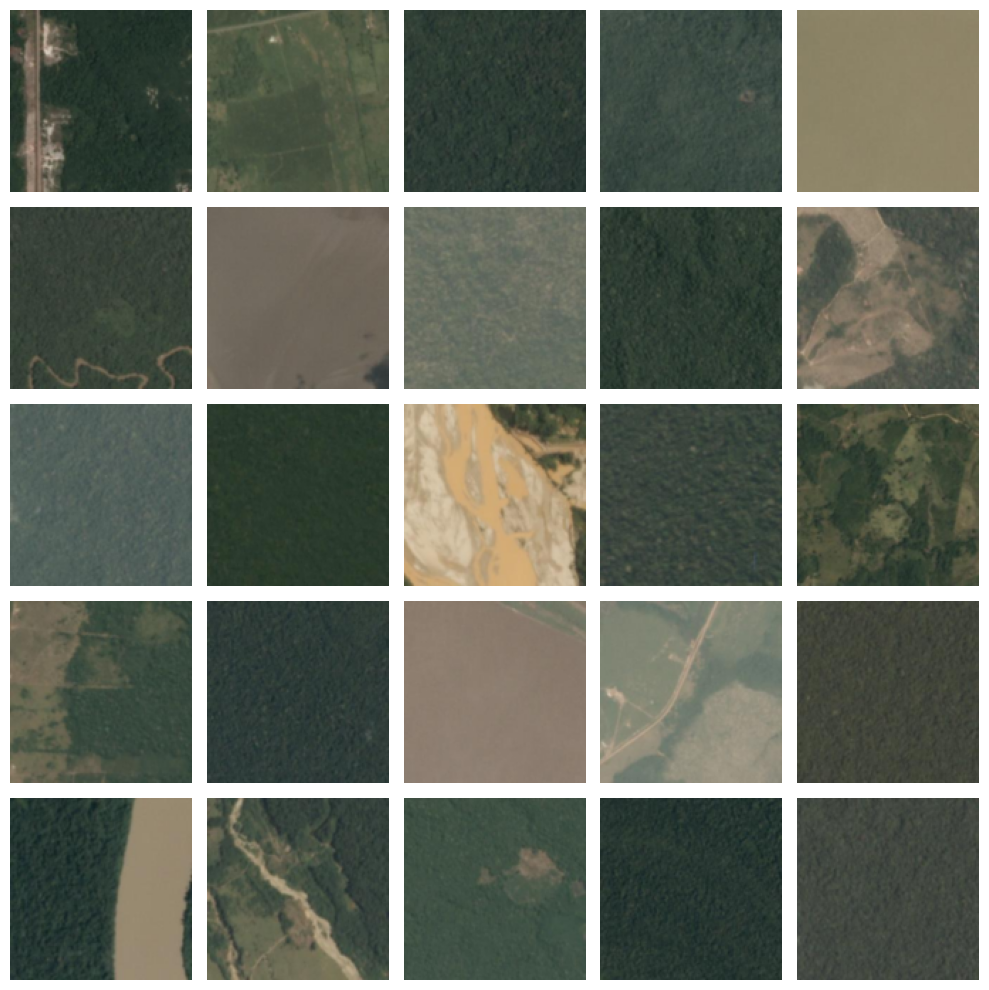

In [17]:
show_image(x, idx=25)

Shape original recebido: torch.Size([32, 3, 128, 128])
Shape após permute (Batch): torch.Size([32, 128, 128, 3])


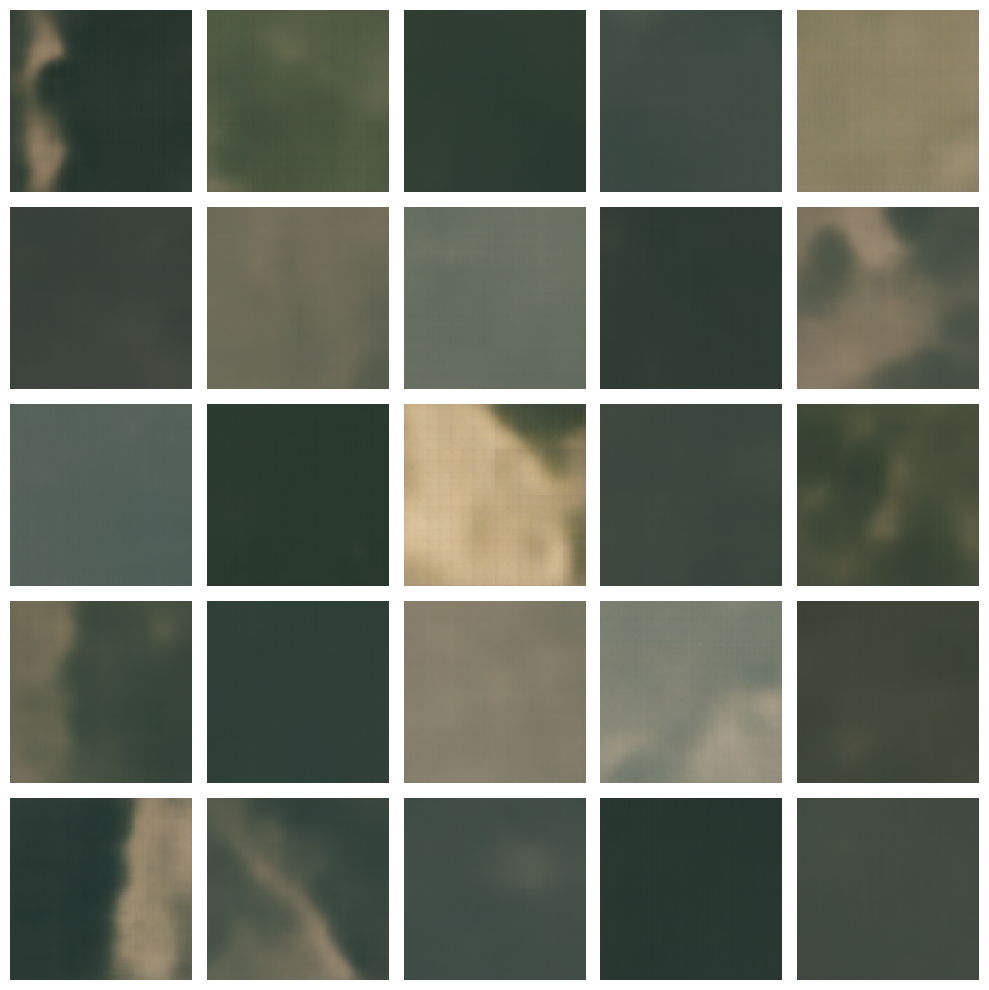

In [18]:
show_image(y_hat, idx=25)

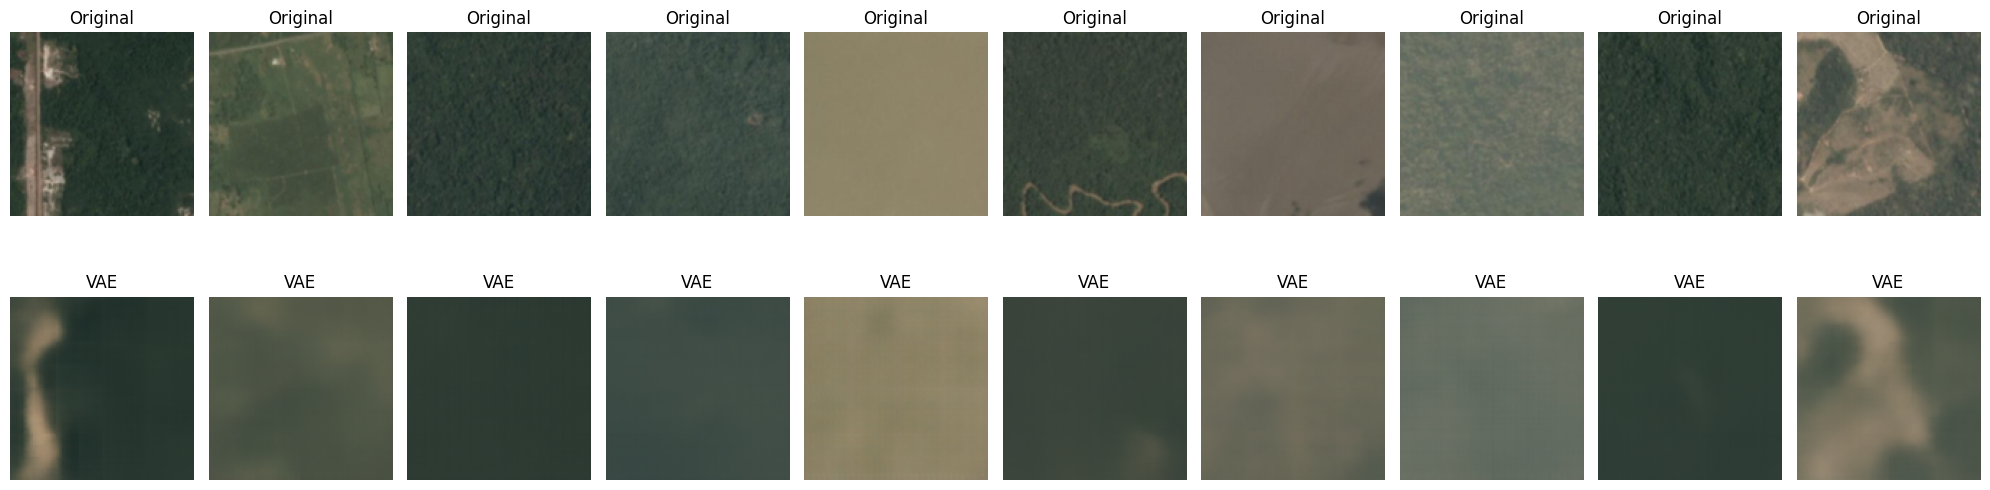

In [19]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    for x, _ in test_loader:
        # x já vem do loader como [B, 3, H, W]
        x = x.to(DEVICE)
        y_hat, _, _ = model(x)
        break

n = 10
plt.figure(figsize=(20, 6)) # Aumentei um pouco a altura para caber melhor os títulos

for i in range(n):
    # --- Imagem Original ---
    ax = plt.subplot(2, n, i + 1)

    # Prepara a imagem: move canais para o final [3, 28, 28] -> [28, 28, 3]
    img_original = x[i].cpu().permute(1, 2, 0)

    plt.imshow(img_original)
    plt.title("Original")
    ax.axis('off')

    # --- Imagem Reconstruída ---
    ax = plt.subplot(2, n, i + 1 + n)

    # Mesmo processo para a reconstrução
    img_reconstruida = y_hat[i].cpu().permute(1, 2, 0)

    plt.imshow(img_reconstruida)
    plt.title("VAE")
    ax.axis('off')

plt.tight_layout()
plt.show()